# 02 — Exploratory Data Analysis

**Project:** Bitcoin Trend Prediction
**Input:** `data/processed/btc_usd_daily_2014_2026.csv` (the cleaned, merged file from notebook 01)
**Goal:** understand the data *before* I model it — what the price and returns actually look like, whether they're predictable, and what that means for the models I'll build later.

I'm treating this like a proper lab notebook: every chart and test has a sentence on *why* I ran it and what it tells me. The whole point of EDA is to let the data set the agenda for modelling, instead of me guessing.

**What I expect to find (hypotheses up front, so I can't fool myself later):**
1. Price is **non-stationary** (it trends and explodes), so I'll have to model *returns*, not price.
2. Returns have **fat tails** — extreme days happen far more than a Normal distribution allows.
3. Returns themselves are **close to unpredictable** (weak-form efficiency), but their *volatility* clusters — calm periods and wild periods bunch together. That clustering is what motivates the GARCH work in notebook 04.

Let's see if the data agrees.

## Setup

First the little bootstrap that lets me `import paths` no matter where the notebook is run from (it climbs up until it finds `paths.py` at the project root). Then all imports in one place.

In [1]:
import sys
from pathlib import Path

# climb to the project root (folder containing paths.py) and put it on sys.path
_p = Path.cwd()
while not (_p / "paths.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paths

print("Project root:", paths.ROOT)

Project root: D:\Bitcoin-Trend-Prediction


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

# where this notebook saves its outputs
STAGE = "02_eda"
FIG = paths.figures_dir(STAGE)     # outputs/02_eda/figures/
TAB = paths.tables_dir(STAGE)      # outputs/02_eda/tables/

TRADING_DAYS = 365   # crypto trades every day, so I annualise with 365, not 252
print("Figures ->", FIG)
print("Tables  ->", TAB)

Figures -> D:\Bitcoin-Trend-Prediction\outputs\02_eda\figures
Tables  -> D:\Bitcoin-Trend-Prediction\outputs\02_eda\tables


## Phase 1 — Load & integrity check

I cleaned this file in notebook 01, but I never just *trust* a file — I re-confirm the basics: the date range, that there are no gaps, and how many rows came from each source.

In [3]:
df = pd.read_csv(paths.PROCESSED_FILE, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df = df.set_index("date")

print("Shape:", df.shape)
print("Range:", df.index.min().date(), "->", df.index.max().date())
print("Nulls:", int(df.isnull().sum().sum()))

# gap check
full = pd.date_range(df.index.min(), df.index.max(), freq="D")
print("Missing calendar days:", len(set(full) - set(df.index)))

print("\nRows per source:")
print(df["source"].value_counts())
df.head()

Shape: (4219, 7)
Range: 2014-11-28 -> 2026-06-16
Nulls: 0
Missing calendar days: 0

Rows per source:
source
binance          3089
early-history    1130
Name: count, dtype: int64


,open,high,low,close,volume_btc,volume_usd,source
date,,,,,,,
2014-11-28,363.59,381.34,360.57,376.28,8617.15,3220878.18,early-history
2014-11-29,376.42,386.60,372.25,376.72,7245.19,2746157.05,early-history
2014-11-30,376.57,381.99,373.32,373.34,3046.33,1145566.61,early-history
2014-12-01,376.40,382.31,373.03,378.39,6660.56,2520662.37,early-history
2014-12-02,378.39,382.86,375.23,379.25,6832.53,2593576.46,early-history


4,219 continuous daily rows, no gaps, no nulls — the cleaning held. The `early-history` rows (2014–2017, from CryptoDataDownload) hand off to `binance` at 2018, exactly as designed.

## Phase 2 — Price over time, and why log scale is non-negotiable

Bitcoin went from roughly \$370 to \$66,000 over this period — that's ~180×. On a **linear** axis, the entire 2014–2019 history gets squashed into a flat line near zero, and you literally cannot see the 2017 bull run. On a **log** axis, equal *percentage* moves take equal vertical space, so every era is visible. For any asset that grows by orders of magnitude, log scale is the honest default.

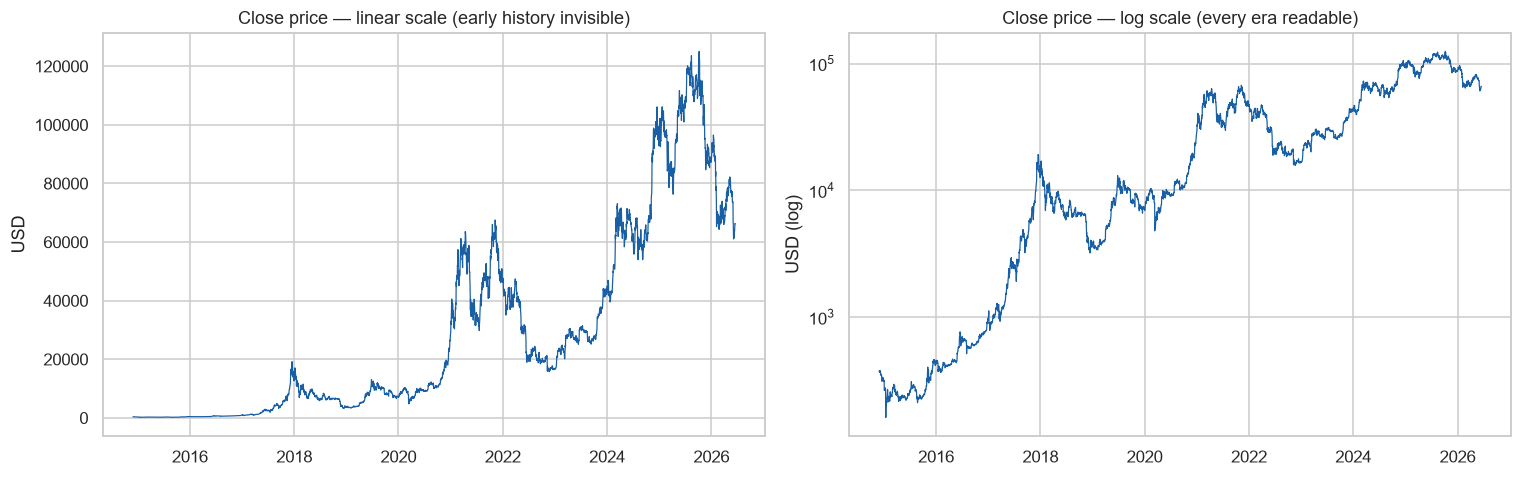

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(df.index, df["close"], color="#185FA5", lw=0.8)
axes[0].set_title("Close price — linear scale (early history invisible)")
axes[0].set_ylabel("USD")

axes[1].plot(df.index, df["close"], color="#185FA5", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Close price — log scale (every era readable)")
axes[1].set_ylabel("USD (log)")
fig.tight_layout()
fig.savefig(FIG / "price_linear_vs_log.png", bbox_inches="tight")
plt.show()

### Drawdowns: how painful were the crashes?

A drawdown is how far price has fallen from its highest point so far. The "underwater" plot below shows it — long stretches deep underwater are the bear markets (2014–15, 2018, 2022). This frames just how violent Bitcoin's cycles are, which matters when I later judge whether a trading strategy's drawdown is acceptable.

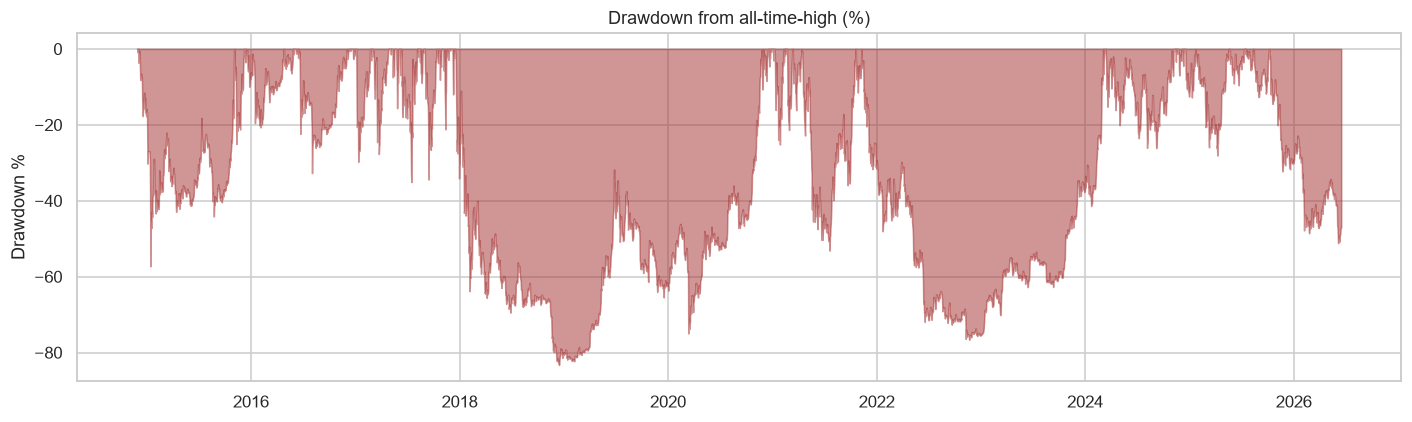

Worst drawdown: -83.3% on 2018-12-15


In [5]:
running_max = df["close"].cummax()
drawdown = df["close"] / running_max - 1.0

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df.index, drawdown * 100, 0, color="#A32D2D", alpha=0.5)
ax.set_title("Drawdown from all-time-high (%)")
ax.set_ylabel("Drawdown %")
fig.tight_layout()
fig.savefig(FIG / "drawdown_underwater.png", bbox_inches="tight")
plt.show()

print("Worst drawdown: %.1f%% on %s" % (drawdown.min() * 100, drawdown.idxmin().date()))

## Phase 3 — Returns and fat tails (rigor starts here)

I model **log returns**, $r_t = \ln(P_t / P_{t-1})$, not raw price. Log returns are additive over time and roughly symmetric, which is what the statistics assume. The first thing I want to know: are they Normally distributed? (Spoiler from finance: almost never.)

In [6]:
df["log_ret"] = np.log(df["close"]).diff()
rets = df["log_ret"].dropna()

desc = {
    "mean (daily)": rets.mean(),
    "std (daily)": rets.std(),
    "skew": stats.skew(rets),
    "excess kurtosis": stats.kurtosis(rets),   # 0 for a Normal
    "annualised vol": rets.std() * np.sqrt(TRADING_DAYS),
    "min day": rets.min(),
    "max day": rets.max(),
}
summary = pd.Series(desc).round(4)
summary.to_csv(TAB / "returns_summary.csv")
summary

mean (daily)        0.0012
std (daily)         0.0356
skew               -0.8457
excess kurtosis    15.0225
annualised vol      0.6793
min day            -0.5026
max day             0.2538
dtype: float64

**Excess kurtosis** is the headline number. A Normal distribution has excess kurtosis of 0; anything large means heavy tails — extreme days are far more common than a bell curve predicts. For Bitcoin I expect a big number. Let me *see* it: a histogram of returns with a Normal curve laid on top.

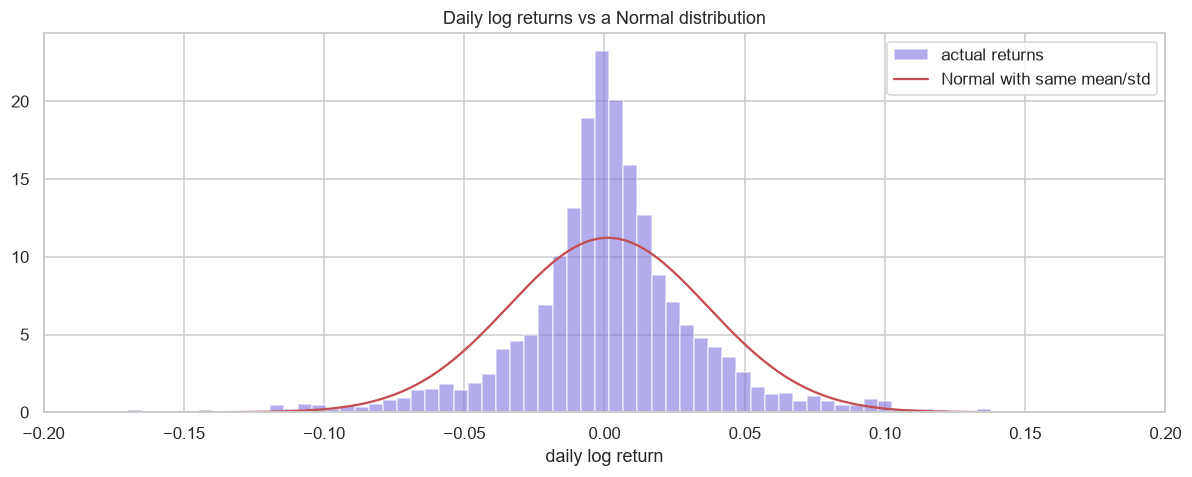

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(rets, bins=150, density=True, color="#7F77DD", alpha=0.6, label="actual returns")
x = np.linspace(rets.min(), rets.max(), 500)
ax.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()), "r-", lw=1.5,
        label="Normal with same mean/std")
ax.set_xlim(-0.2, 0.2)
ax.set_title("Daily log returns vs a Normal distribution")
ax.set_xlabel("daily log return")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "returns_hist_vs_normal.png", bbox_inches="tight")
plt.show()

You can see the actual returns are *taller and skinnier* in the middle and have *fatter tails* than the red Normal curve — classic financial-returns shape. A QQ-plot makes the tails unmistakable: if returns were Normal, the points would lie on the straight line. They won't at the ends.

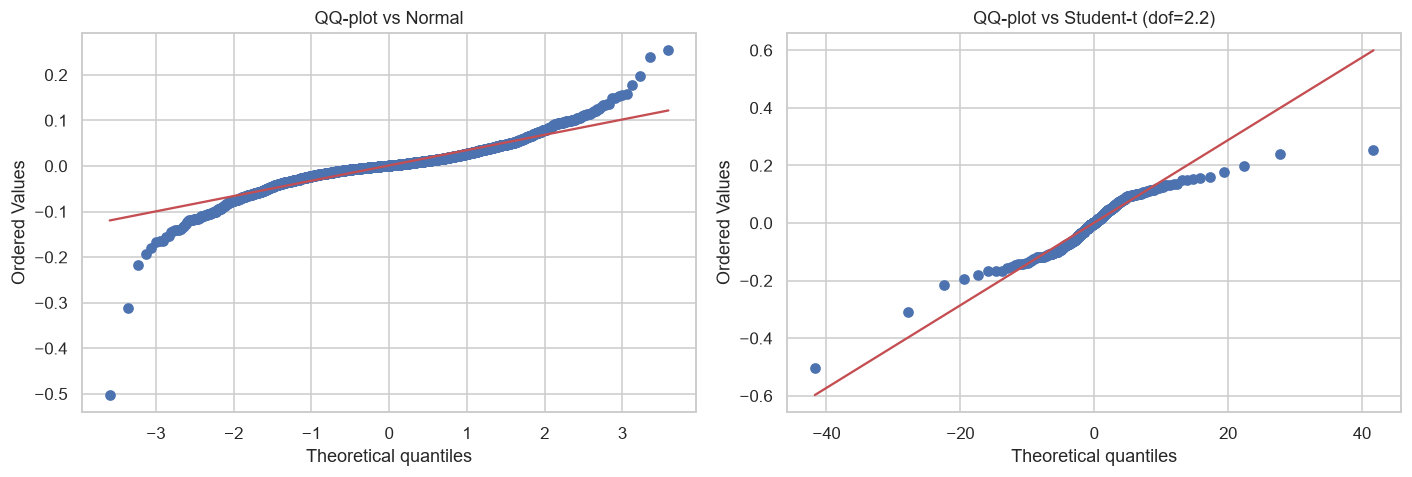

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
stats.probplot(rets, dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot vs Normal")
# vs Student-t (fit dof first)
t_params = stats.t.fit(rets)
stats.probplot(rets, dist=stats.t, sparams=(t_params[0],), plot=axes[1])
axes[1].set_title(f"QQ-plot vs Student-t (dof={t_params[0]:.1f})")
fig.tight_layout()
fig.savefig(FIG / "qqplots.png", bbox_inches="tight")
plt.show()

### Which distribution actually fits? (MLE + AIC)

I fit three candidate distributions by maximum likelihood and compare them with **AIC** (lower = better, penalised for extra parameters) and the **KS test**. This is the OGDC-style move — and like their stock, I bet the Student-t wins decisively over the Normal because of those tails.

In [9]:
def aic(loglik, k):
    return 2 * k - 2 * loglik

candidates = {
    "Normal": (stats.norm, 2),
    "Student-t": (stats.t, 3),
    "Laplace": (stats.laplace, 2),
}
rows = []
for name, (dist, k) in candidates.items():
    params = dist.fit(rets)
    ll = np.sum(dist.logpdf(rets, *params))
    ks_stat, ks_p = stats.kstest(rets, dist.cdf, args=params)
    rows.append({"dist": name, "loglik": ll, "AIC": aic(ll, k),
                 "KS_stat": ks_stat, "KS_p": ks_p})
fit_table = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
fit_table.round(2).to_csv(TAB / "distribution_fit.csv", index=False)
fit_table.round(3)

,dist,loglik,AIC,KS_stat,KS_p
0,Laplace,8770.481,-17536.962,0.034,0.00
1,Student-t,8763.927,-17521.854,0.023,0.02
2,Normal,8089.243,-16174.485,0.104,0.00


In [10]:
# Formal normality tests
jb_stat, jb_p = stats.jarque_bera(rets)
sh_stat, sh_p = stats.shapiro(rets.sample(min(5000, len(rets)), random_state=0))  # Shapiro caps at ~5000
print(f"Jarque-Bera: stat={jb_stat:,.0f}  p={jb_p:.3g}   -> {'REJECT Normal' if jb_p < 0.05 else 'cannot reject'}")
print(f"Shapiro-Wilk (5k sample): W={sh_stat:.4f}  p={sh_p:.3g}  -> {'REJECT Normal' if sh_p < 0.05 else 'cannot reject'}")

Jarque-Bera: stat=40,166  p=0   -> REJECT Normal
Shapiro-Wilk (5k sample): W=0.8940  p=3.63e-47  -> REJECT Normal


**Takeaway:** returns are emphatically *not* Normal — fat-tailed, best described by a Student-t with low degrees of freedom. Practically, this means (a) any model assuming Gaussian errors will badly underestimate crash risk, and (b) when I build the deep-learning model later, I should be wary of loss functions that punish outliers too harshly.

## Phase 4 — Stationarity & autocorrelation (the GARCH motivation)

This is the most important phase for deciding *what* to model.

**Stationarity** (via the Augmented Dickey-Fuller test): a series is stationary if its statistical properties don't drift over time. Models need stationary inputs. I expect **price** to fail the test (it trends) and **returns** to pass.

In [11]:
def adf_report(series, label):
    stat, p, lags, n, crit, _ = adfuller(series.dropna(), autolag="AIC")
    verdict = "STATIONARY" if p < 0.05 else "non-stationary"
    print(f"{label:18} ADF={stat:8.3f}  p={p:.3g}  -> {verdict}")
    return {"series": label, "adf": stat, "p": p, "verdict": verdict}

adf_rows = [adf_report(df["close"], "price"),
            adf_report(df["log_ret"], "log returns")]
pd.DataFrame(adf_rows).to_csv(TAB / "adf_tests.csv", index=False)

price              ADF=  -1.290  p=0.634  -> non-stationary


log returns        ADF= -67.853  p=0  -> STATIONARY


As expected: price is non-stationary, returns are stationary. **So I model returns.** This decision carries all the way through to the LSTM in notebook 07 — it'll be fed returns/scaled features, never raw price.

### The key plot of the whole EDA

Now the payoff. I compare the autocorrelation of **returns** against the autocorrelation of **squared returns**:
- If *returns* have ~no autocorrelation → I can't predict tomorrow's direction from recent returns alone (weak-form efficiency). Honest, expected, and the reason accuracy will be modest.
- If *squared returns* (a proxy for volatility) have strong, slowly-decaying autocorrelation → volatility **clusters**. Big days follow big days. That's the empirical justification for GARCH.

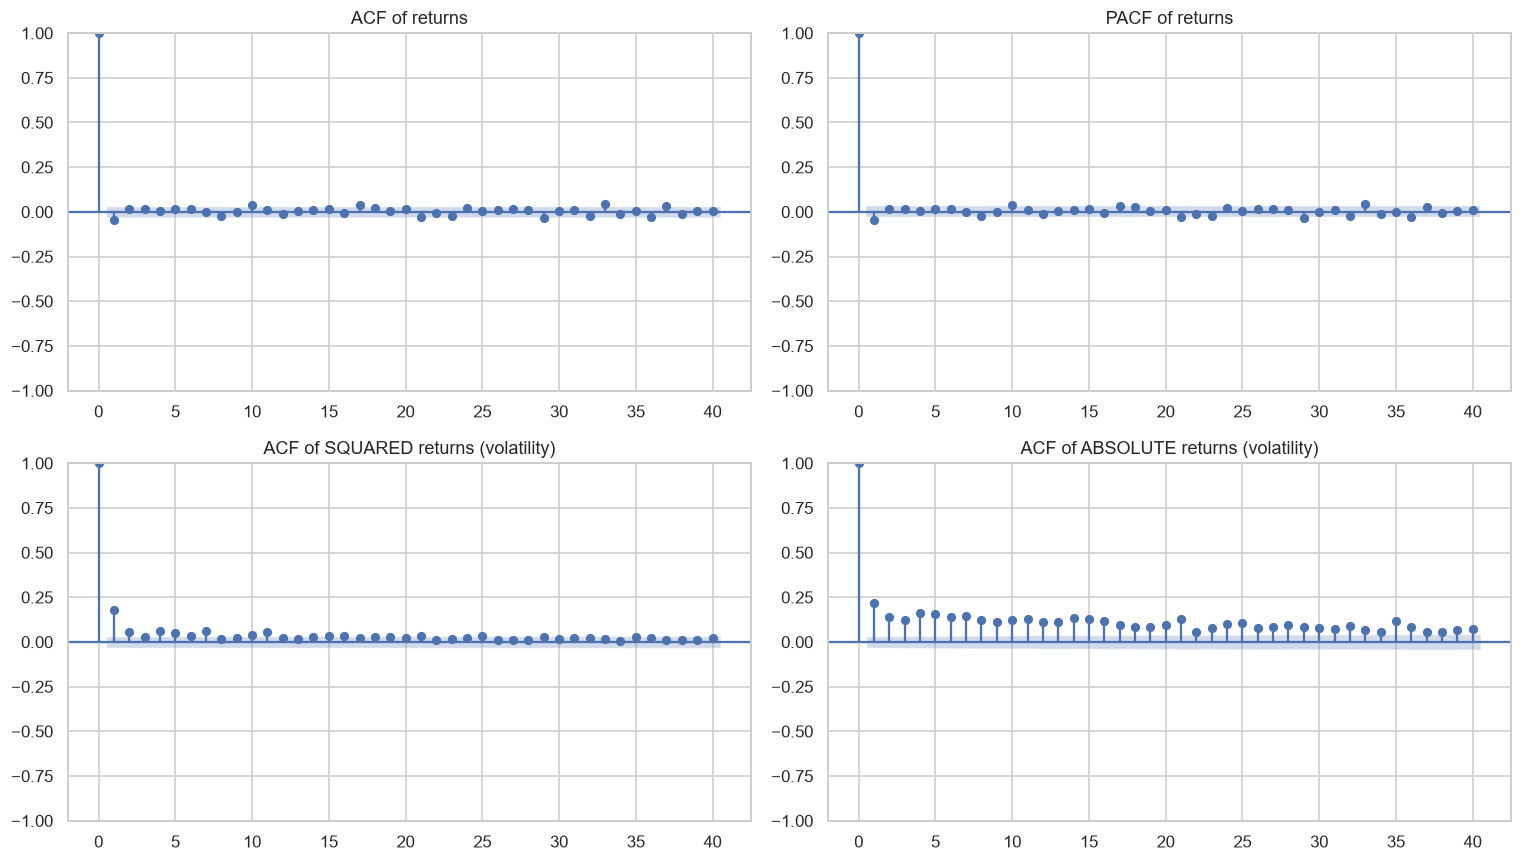

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(rets, lags=40, ax=axes[0, 0]); axes[0, 0].set_title("ACF of returns")
plot_pacf(rets, lags=40, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF of returns")
plot_acf(rets**2, lags=40, ax=axes[1, 0]); axes[1, 0].set_title("ACF of SQUARED returns (volatility)")
plot_acf(rets.abs(), lags=40, ax=axes[1, 1]); axes[1, 1].set_title("ACF of ABSOLUTE returns (volatility)")
fig.tight_layout()
fig.savefig(FIG / "acf_returns_vs_volatility.png", bbox_inches="tight")
plt.show()

In [13]:
# Ljung-Box: is there significant autocorrelation in the first 10 lags?
lb_ret = acorr_ljungbox(rets, lags=[10], return_df=True)
lb_sq = acorr_ljungbox(rets**2, lags=[10], return_df=True)
print("Ljung-Box on returns        : p =", float(lb_ret["lb_pvalue"].iloc[0]))
print("Ljung-Box on squared returns: p =", float(lb_sq["lb_pvalue"].iloc[0]))
print("\nIf returns' p is largish but squared-returns' p ~ 0,")
print("that's the classic signature: little direction signal, strong volatility clustering.")

Ljung-Box on returns        : p = 0.020083855308419708
Ljung-Box on squared returns: p = 1.302307279429344e-38

If returns' p is largish but squared-returns' p ~ 0,
that's the classic signature: little direction signal, strong volatility clustering.


**Interpretation:** the top row (returns) shows little usable autocorrelation — direction is hard, as the efficiency story predicts. The bottom row (squared/absolute returns) shows strong, slowly-decaying bars — volatility clustering is real and persistent. Together these say: *don't expect to predict direction well, but volatility is very much modellable.* That's exactly why notebook 04 fits GARCH.

## Phase 5 — Volatility & volume

Let me look directly at volatility over time, and at the returns series itself where the clustering is visible to the naked eye.

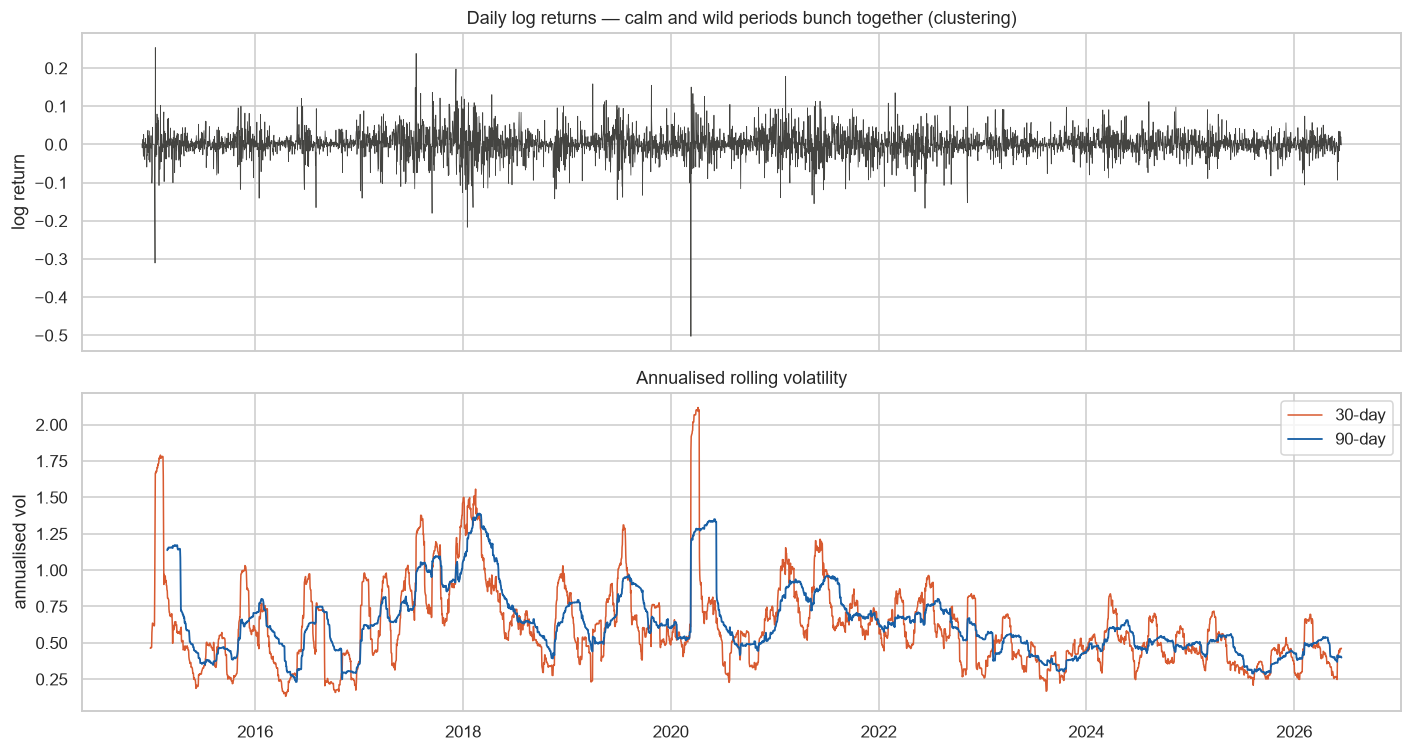

In [14]:
roll_vol = df["log_ret"].rolling(30).std() * np.sqrt(TRADING_DAYS)
roll_vol_90 = df["log_ret"].rolling(90).std() * np.sqrt(TRADING_DAYS)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df.index, df["log_ret"], color="#444441", lw=0.5)
axes[0].set_title("Daily log returns — calm and wild periods bunch together (clustering)")
axes[0].set_ylabel("log return")
axes[1].plot(roll_vol.index, roll_vol, label="30-day", color="#D85A30", lw=1)
axes[1].plot(roll_vol_90.index, roll_vol_90, label="90-day", color="#185FA5", lw=1.2)
axes[1].set_title("Annualised rolling volatility")
axes[1].set_ylabel("annualised vol")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "volatility_over_time.png", bbox_inches="tight")
plt.show()

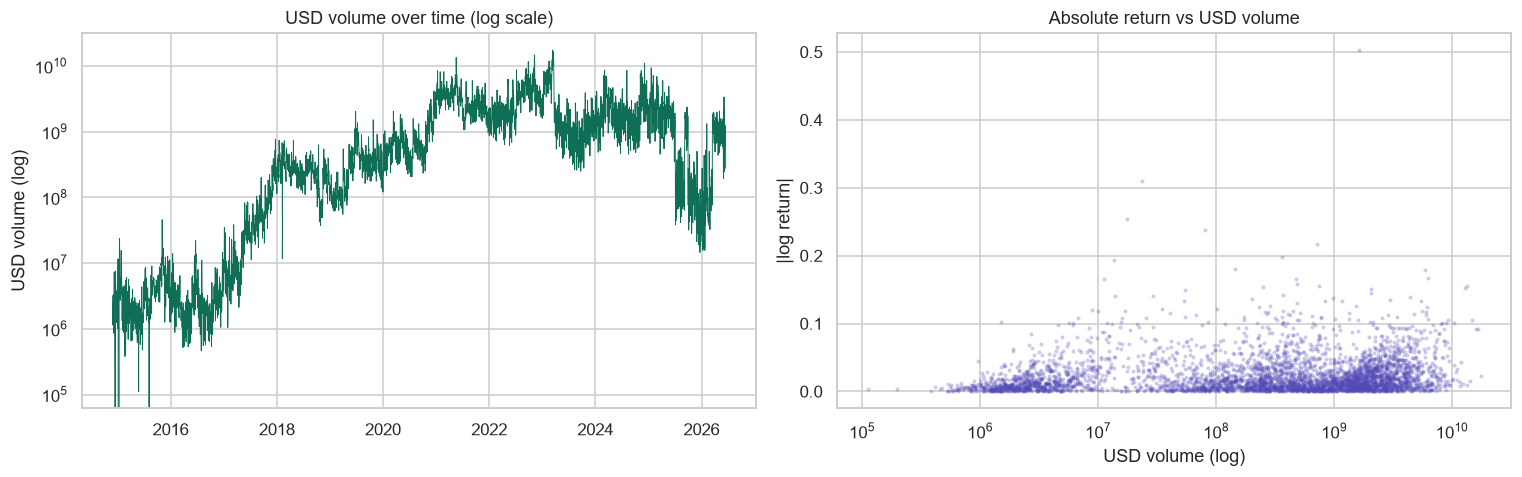

Correlation between log-volume and |return|: 0.127


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(df.index, df["volume_usd"], color="#0F6E56", lw=0.6)
axes[0].set_yscale("log")
axes[0].set_title("USD volume over time (log scale)")
axes[0].set_ylabel("USD volume (log)")

axes[1].scatter(df["volume_usd"], df["log_ret"].abs(), s=3, alpha=0.2, color="#534AB7")
axes[1].set_xscale("log")
axes[1].set_title("Absolute return vs USD volume")
axes[1].set_xlabel("USD volume (log)")
axes[1].set_ylabel("|log return|")
fig.tight_layout()
fig.savefig(FIG / "volume_analysis.png", bbox_inches="tight")
plt.show()

corr_df = pd.DataFrame({
    "log_vol": np.log(df["volume_usd"].replace(0, np.nan)),
    "abs_ret": df["log_ret"].abs(),
}).dropna()
corr = corr_df["log_vol"].corr(corr_df["abs_ret"])
print(f"Correlation between log-volume and |return|: {corr:.3f}")

Volume has grown by orders of magnitude (hence log scale), and bigger-volume days tend to coincide with bigger-magnitude moves — a positive volume/|return| correlation. That hints volume could be a useful feature for predicting *volatility*, even if not direction.

## Phase 6 — Calendar effects (a crypto-specific angle)

Stocks don't trade on weekends; **Bitcoin does**. So I can ask a question a stock dataset can't: do weekends behave differently from weekdays? I also check day-of-week and month effects, while being skeptical — with markets this efficient, I expect most of these to be statistically flat (just like OGDC's ANOVA found no year effect).

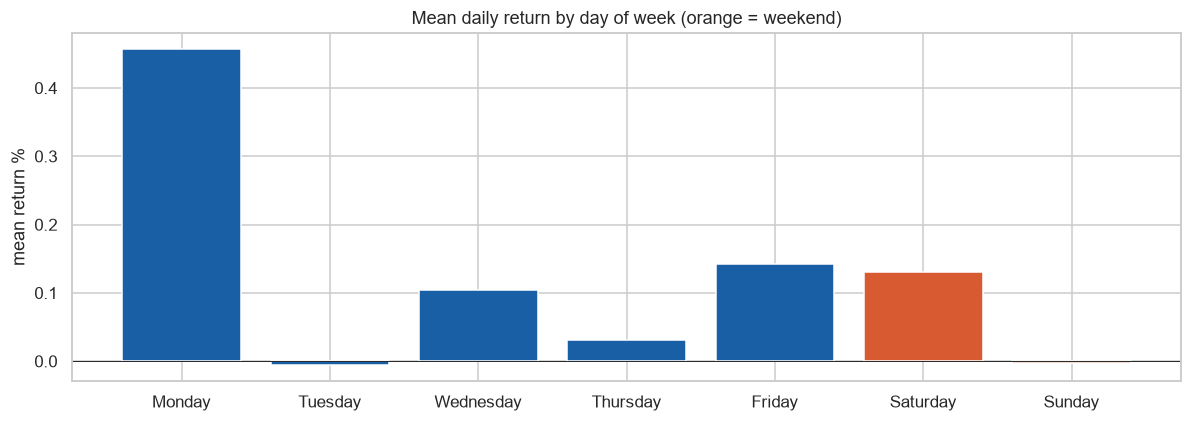

Weekend mean: 0.0641%   Weekday mean: 0.1460%
Welch t-test weekend vs weekday: t=-0.78, p=0.438 -> no significant difference


In [16]:
tmp = df.copy()
tmp["dow"] = tmp.index.day_name()
tmp["is_weekend"] = tmp.index.dayofweek >= 5

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_mean = tmp.groupby("dow")["log_ret"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#185FA5" if d not in ("Saturday","Sunday") else "#D85A30" for d in dow_order]
ax.bar(dow_order, dow_mean.values * 100, color=colors)
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Mean daily return by day of week (orange = weekend)")
ax.set_ylabel("mean return %")
fig.tight_layout()
fig.savefig(FIG / "day_of_week_effect.png", bbox_inches="tight")
plt.show()

wk = tmp.loc[tmp["is_weekend"], "log_ret"]
wd = tmp.loc[~tmp["is_weekend"], "log_ret"]
t_stat, t_p = stats.ttest_ind(wk.dropna(), wd.dropna(), equal_var=False)
print(f"Weekend mean: {wk.mean()*100:.4f}%   Weekday mean: {wd.mean()*100:.4f}%")
print(f"Welch t-test weekend vs weekday: t={t_stat:.2f}, p={t_p:.3f} -> "
      f"{'different' if t_p < 0.05 else 'no significant difference'}")

## Phase 7 — Just how predictable is direction? (honest setup for modelling)

Before I get excited about models, I want a sober baseline read on predictability. Two quick probes:

1. **Runs test** — are up/down days arranged randomly, or do they streak? If random, knowing today's sign tells me nothing about tomorrow's.
2. **Lag-1 scatter** — today's return vs yesterday's. A shapeless blob = no linear relationship.

In [17]:
# Runs test on the sign of returns (manual, so I understand it)
signs = np.sign(rets.values)
signs = signs[signs != 0]
n_pos = int((signs > 0).sum())
n_neg = int((signs < 0).sum())
runs = 1 + int((signs[1:] != signs[:-1]).sum())
exp_runs = 1 + 2 * n_pos * n_neg / (n_pos + n_neg)
var_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n_pos - n_neg)) / \
           ((n_pos + n_neg) ** 2 * (n_pos + n_neg - 1))
z = (runs - exp_runs) / np.sqrt(var_runs)
p_runs = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Runs: observed={runs}, expected={exp_runs:.0f}, Z={z:.3f}, p={p_runs:.3f}")
print("-> " + ("non-random (streaky)" if p_runs < 0.05 else "indistinguishable from random"))

Runs: observed=2242, expected=2102, Z=4.322, p=0.000
-> non-random (streaky)


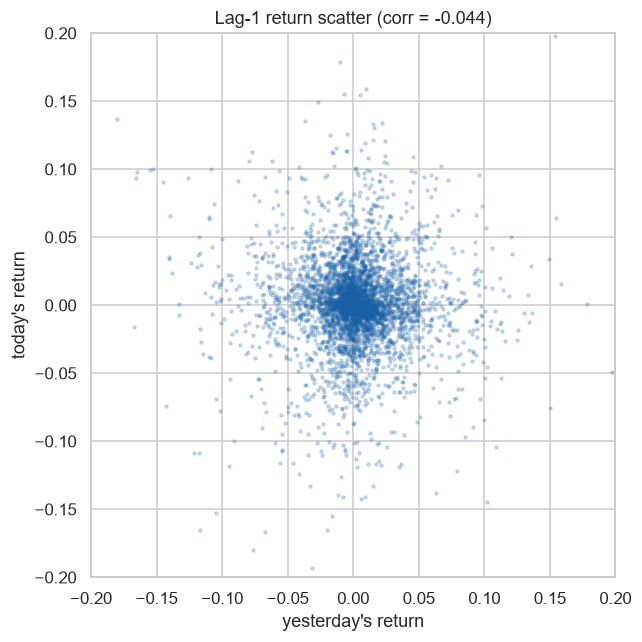

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rets.shift(1), rets, s=4, alpha=0.2, color="#185FA5")
ax.set_xlabel("yesterday's return")
ax.set_ylabel("today's return")
ax.set_title(f"Lag-1 return scatter (corr = {rets.autocorr(1):.3f})")
ax.set_xlim(-0.2, 0.2); ax.set_ylim(-0.2, 0.2)
fig.tight_layout()
fig.savefig(FIG / "lag1_scatter.png", bbox_inches="tight")
plt.show()

## Phase 8 — Takeaways and what they mean for modelling

What the data told me, and how each finding feeds the rest of the project:

1. **Price is non-stationary; returns are stationary.** → Every model works on returns/engineered features, never raw price. (Sets up notebooks 05–07.)
2. **Returns are fat-tailed (Student-t, not Normal).** → Crash risk is bigger than Gaussian intuition; be careful with outlier-sensitive losses in the deep-learning model.
3. **Returns show little autocorrelation, but volatility clusters strongly.** → Direction is hard (honest, modest accuracy ahead — no leakage mirages), but volatility is very modellable. This is the empirical green light for **GARCH** in notebook 04.
4. **Volume tracks volatility.** → A candidate feature for the volatility side of the problem.
5. **Calendar effects are weak.** → Don't lean on day-of-week as a strong predictor.

**Concrete plan this EDA justifies:**
- Notebook 03: formal stationarity/distribution tests + ARMA (confirm direction is near-unpredictable).
- Notebook 04: GARCH family for the volatility clustering I just saw.
- Notebook 05: engineer features on *returns* + add the on-chain data.
- Notebooks 06–07: classical ML baseline, then the LSTM/GRU benchmark — judged honestly against a coin-flip and against each other.

All figures saved to `outputs/02_eda/figures/`, all tables to `outputs/02_eda/tables/`.